In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Inisialisasi Spark LENGKAP dengan konfigurasi MinIO
spark = SparkSession.builder \
    .appName("ML_Turnover_Final_Evaluation") \
    .config("spark.jars.packages", "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262") \
    .config("spark.hadoop.fs.s3a.endpoint", "http://bda-minio:9000") \
    .config("spark.hadoop.fs.s3a.access.key", "admin") \
    .config("spark.hadoop.fs.s3a.secret.key", "password123") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .getOrCreate()

print("✅ Spark Session & Library berhasil diinisialisasi!")

✅ Spark Session & Library berhasil diinisialisasi!


In [2]:
minio_gold_path = "s3a://datalake/gold/employee-attrition/"
print(f"📥 Membaca data Parquet dari: {minio_gold_path}...")
gold_df = spark.read.parquet(minio_gold_path)

print("⚙️ Membagi data untuk proses Machine Learning...")
train_split, test_split = gold_df.randomSplit([0.8, 0.2], seed=42)

# Siapkan Evaluator Global
mc_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
roc_evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

print(f"  - Data Training : {train_split.count():,} baris")
print(f"  - Data Testing  : {test_split.count():,} baris")
print("✅ Data siap untuk dimasukkan ke pemodelan!")

📥 Membaca data Parquet dari: s3a://datalake/gold/employee-attrition/...
⚙️ Membagi data untuk proses Machine Learning...
  - Data Training : 47,836 baris
  - Data Testing  : 11,762 baris
✅ Data siap untuk dimasukkan ke pemodelan!


In [3]:
print("⏳ Melatih Model Baseline (numTrees=100, maxDepth=10)...")

# Model awal sesuai parameter acuan di PRD
rf_baseline = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=100, maxDepth=10, seed=42)
baseline_model = rf_baseline.fit(train_split)

# Prediksi menggunakan data testing
baseline_preds = baseline_model.transform(test_split)

# Hitung seluruh metrik untuk Model Baseline
metrics_base = {
    "Accuracy": mc_evaluator.evaluate(baseline_preds, {mc_evaluator.metricName: "accuracy"}),
    "F1 Score": mc_evaluator.evaluate(baseline_preds, {mc_evaluator.metricName: "f1"}),
    "Precision": mc_evaluator.evaluate(baseline_preds, {mc_evaluator.metricName: "weightedPrecision"}),
    "Recall": mc_evaluator.evaluate(baseline_preds, {mc_evaluator.metricName: "weightedRecall"}),
    "AUC-ROC": roc_evaluator.evaluate(baseline_preds)
}

print("--- 📊 HASIL MODEL BASELINE (SEBELUM TUNING) ---")
for metric_name, score in metrics_base.items():
    print(f"{metric_name:<10} : {score:.4f}")

⏳ Melatih Model Baseline (numTrees=100, maxDepth=10)...
--- 📊 HASIL MODEL BASELINE (SEBELUM TUNING) ---
Accuracy   : 0.7432
F1 Score   : 0.7431
Precision  : 0.7431
Recall     : 0.7432
AUC-ROC    : 0.8287


In [4]:
print("⏳ Memulai Hyperparameter Tuning dengan Cross Validation...")

# 1. Setup Cangkang Model Kosong
rf_tuned = RandomForestClassifier(labelCol="label", featuresCol="features", seed=42)

# 2. Setup Grid Search (Versi Aman: 27 Putaran Pelatihan)
paramGrid = (ParamGridBuilder()
             .addGrid(rf_tuned.numTrees, [20, 50, 100])
             .addGrid(rf_tuned.maxDepth, [5, 8, 12])
             .build())

# 3. Eksekusi Cross Validation dengan juri penilaian utama AUC-ROC
cv = CrossValidator(estimator=rf_tuned,
                    estimatorParamMaps=paramGrid,
                    evaluator=roc_evaluator,
                    numFolds=3)

cv_model = cv.fit(train_split)
best_model = cv_model.bestModel

# Lakukan prediksi menggunakan model pemenang terbaik
best_preds = best_model.transform(test_split)

# Hitung seluruh metrik untuk Model Terbaik (Tuned)
metrics_tuned = {
    "Accuracy": mc_evaluator.evaluate(best_preds, {mc_evaluator.metricName: "accuracy"}),
    "F1 Score": mc_evaluator.evaluate(best_preds, {mc_evaluator.metricName: "f1"}),
    "Precision": mc_evaluator.evaluate(best_preds, {mc_evaluator.metricName: "weightedPrecision"}),
    "Recall": mc_evaluator.evaluate(best_preds, {mc_evaluator.metricName: "weightedRecall"}),
    "AUC-ROC": roc_evaluator.evaluate(best_preds)
}

print("\n✅ Tuning selesai! Parameter terbaik didapatkan:")
print(f"  - Jumlah Pohon (numTrees) : {best_model.getNumTrees}")
print(f"  - Kedalaman (maxDepth)    : {best_model.getOrDefault('maxDepth')}\n")

print("--- 🏆 HASIL MODEL TERBAIK (SESUDAH TUNING) ---")
for metric_name, score in metrics_tuned.items():
    print(f"{metric_name:<10} : {score:.4f}")

⏳ Memulai Hyperparameter Tuning dengan Cross Validation...

✅ Tuning selesai! Parameter terbaik didapatkan:
  - Jumlah Pohon (numTrees) : 100
  - Kedalaman (maxDepth)    : 12

--- 🏆 HASIL MODEL TERBAIK (SESUDAH TUNING) ---
Accuracy   : 0.7471
F1 Score   : 0.7471
Precision  : 0.7471
Recall     : 0.7471
AUC-ROC    : 0.8319


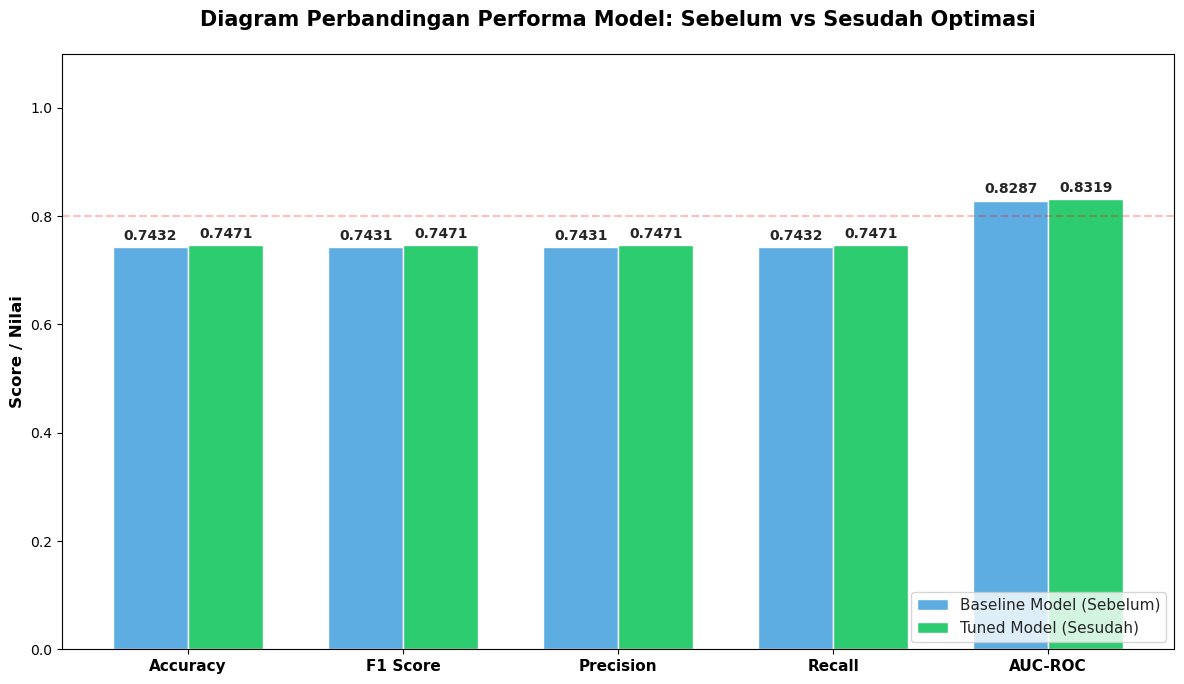

In [5]:
# Ambil label metrik dan nilai skor masing-masing model
labels = list(metrics_base.keys())
base_scores = [metrics_base[m] for m in labels]
tuned_scores = [metrics_tuned[m] for m in labels]

x = np.arange(len(labels))
width = 0.35  # Lebar batang kelompok grafik

fig, ax = plt.subplots(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Plot grafik batang berdampingan (side-by-side)
rects1 = ax.bar(x - width/2, base_scores, width, label='Baseline Model (Sebelum)', color='#5dade2')
rects2 = ax.bar(x + width/2, tuned_scores, width, label='Tuned Model (Sesudah)', color='#2ecc71')

# Atur kosmetik visual diagram
ax.set_ylabel('Score / Nilai', fontsize=12, fontweight='bold')
ax.set_title('Diagram Perbandingan Performa Model: Sebelum vs Sesudah Optimasi', fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim(0, 1.1)

# Fungsi otomatis untuk memunculkan angka presisi di atas diagram batang
def add_value_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

add_value_labels(rects1)
add_value_labels(rects2)

# Garis bantu threshold standar industri (80%)
plt.axhline(y=0.8, color='red', linestyle='--', alpha=0.25)
plt.tight_layout()
plt.show()

In [6]:
# Mengambil daftar bobot kepentingan fitur asli dari model pemenang
importance = best_model.featureImportances.toArray()

try:
    attrs = gold_df.schema["features"].metadata["ml_attr"]["attrs"]
    list_attrs = attrs.get("numeric", []) + attrs.get("binary", []) + attrs.get("nominal", [])

    mapping_data = []
    for x in sorted(list_attrs, key=lambda x: x["idx"]):
        mapping_data.append((x["name"], importance[x["idx"]]))
        
    raw_feat_df = pd.DataFrame(mapping_data, columns=["Encoded_Feature", "Importance"])

    # Fungsi untuk memotong string berekstensi One-Hot Encoding (_ohe_)
    def get_parent_feature(name):
        if "_ohe_" in name:
            return name.split("_ohe_")[0]
        return name

    # Membuat kolom baru berisi nama induk fitur makro
    raw_feat_df["Generalized_Feature"] = raw_feat_df["Encoded_Feature"].apply(get_parent_feature)
    
    # Kelompokkan dan jumlahkan total kontribusi Gini Impurity Decrease-nya
    importance_df = raw_feat_df.groupby("Generalized_Feature")["Importance"].sum().reset_index()
    importance_df = importance_df.sort_values(by="Importance", ascending=False)

    print("--- 🥇 TOP 10 GENERALIZED FEATURE IMPORTANCE SECARA MATEMATIS ---")
    print(importance_df.head(10).to_string(index=False))

except Exception as e:
    print(f"⚠️ Error saat mengekstrak metrik Feature Importance: {e}")

--- 🥇 TOP 10 GENERALIZED FEATURE IMPORTANCE SECARA MATEMATIS ---
 Generalized_Feature  Importance
           Job Level    0.228763
      Marital Status    0.183468
         Remote Work    0.115330
   Work-Life Balance    0.079329
  Distance from Home    0.039947
    Years at Company    0.032493
Number of Promotions    0.032119
  Company Reputation    0.030023
     Education Level    0.029911
                 Age    0.029129


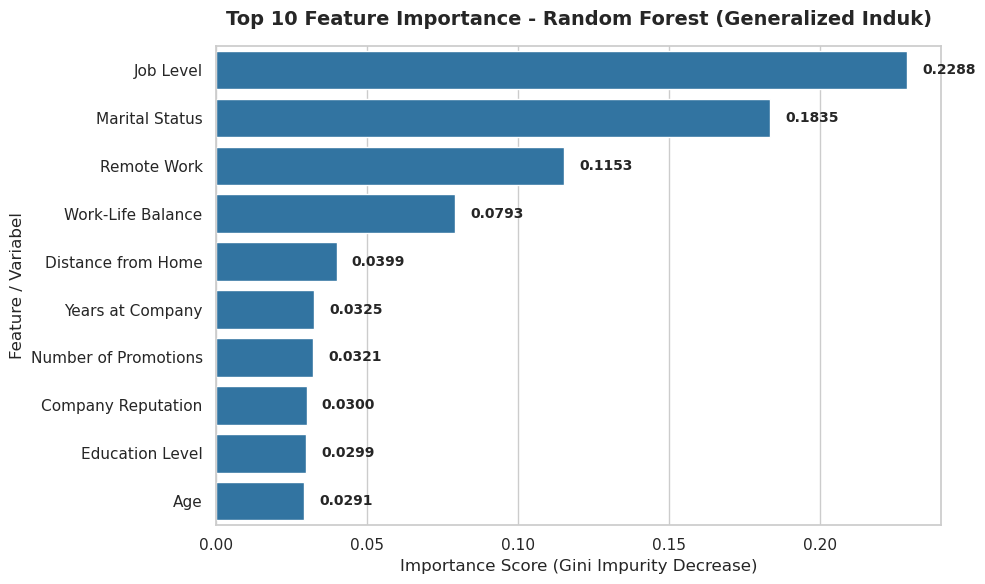

In [7]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Plot bar horizontal menggunakan data agregasi Pandas
sns.barplot(
    x="Importance", 
    y="Generalized_Feature", 
    data=importance_df.head(10), 
    color="#1f77b4"
)

plt.title("Top 10 Feature Importance - Random Forest (Generalized Induk)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Importance Score (Gini Impurity Decrease)", fontsize=12)
plt.ylabel("Feature / Variabel", fontsize=12)

# Mencetak nilai desimal tepat di samping kanan ujung batang grafik
for index, value in enumerate(importance_df.head(10)["Importance"]):
    plt.text(value + 0.005, index, f'{value:.4f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

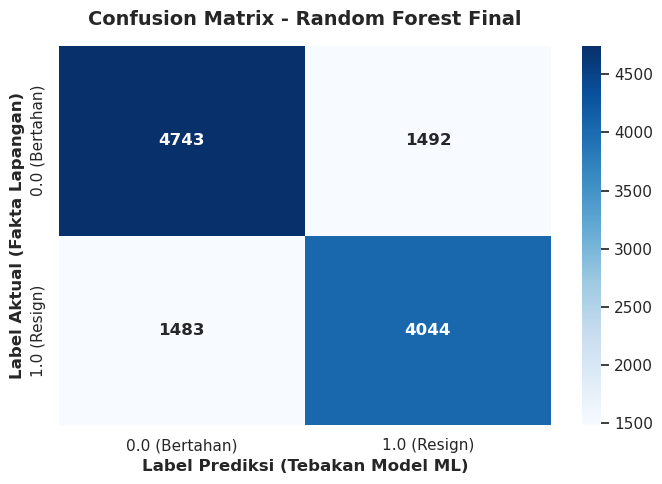

In [8]:
# Membuat crosstab tabular 2x2 dari hasil prediksi PySpark
cm_spark = best_preds.crosstab("label", "prediction").orderBy("label_prediction")
cm_pd = cm_spark.toPandas()

# Mengekstrak susunan nilai array numeriknya saja
cm_matrix = cm_pd[['0.0', '1.0']].values

plt.figure(figsize=(7, 5))

# Plot heatmap menggunakan palet warna biru profesional
sns.heatmap(cm_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["0.0 (Bertahan)", "1.0 (Resign)"], 
            yticklabels=["0.0 (Bertahan)", "1.0 (Resign)"],
            annot_kws={"size": 12, "weight": "bold"})

plt.title('Confusion Matrix - Random Forest Final', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Label Aktual (Fakta Lapangan)', fontsize=12, fontweight='bold')
plt.xlabel('Label Prediksi (Tebakan Model ML)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()